# SVM Kernel Evaluation for Climate Model Simulation Crash Classification

This notebook evaluates four Support Vector Machine (SVM) kernels — **linear, polynomial, RBF, and sigmoid** — for classifying climate model simulation crashes using the [UCI Climate Model Simulation Crashes dataset](https://archive.ics.uci.edu/ml/datasets/climate+model+simulation+crashes), which contains 540 simulation runs described by 18 physical parameters.

The pipeline covers data loading, cleaning, exploratory analysis, kernel comparison, and hyperparameter tuning via GridSearchCV.

**Key question:** Which SVM kernel best separates crashed from non-crashed climate simulations, and does hyperparameter tuning on the RBF kernel close the gap with the linear baseline?

## Dependencies

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


## Data Loading & Exploration

In [ ]:
# Loading data into Python

data = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/00252/pop_failures.dat", sep=r"\s+")
display(data.head())
display(data.tail())

,Study,Run,vconst_corr,vconst_2,vconst_3,vconst_4,vconst_5,vconst_7,ah_corr,ah_bolus,...,efficiency_factor,tidal_mix_max,vertical_decay_scale,convect_corr,bckgrnd_vdc1,bckgrnd_vdc_ban,bckgrnd_vdc_eq,bckgrnd_vdc_psim,Prandtl,outcome
0,1,1,0.859036,0.927825,0.252866,0.298838,0.170521,0.735936,0.428325,0.567947,...,0.245675,0.104226,0.869091,0.997518,0.448620,0.307522,0.858310,0.796997,0.869893,0
1,1,2,0.606041,0.457728,0.359448,0.306957,0.843331,0.934851,0.444572,0.828015,...,0.616870,0.975786,0.914344,0.845247,0.864152,0.346713,0.356573,0.438447,0.512256,1
2,1,3,0.997600,0.373238,0.517399,0.504993,0.618903,0.605571,0.746225,0.195928,...,0.679355,0.803413,0.643995,0.718441,0.924775,0.315371,0.250642,0.285636,0.365858,1
3,1,4,0.783408,0.104055,0.197533,0.421837,0.742056,0.490828,0.005525,0.392123,...,0.471463,0.597879,0.761659,0.362751,0.912819,0.977971,0.845921,0.699431,0.475987,1
4,1,5,0.406250,0.513199,0.061812,0.635837,0.844798,0.441502,0.191926,0.487546,...,0.551543,0.743877,0.312349,0.650223,0.522261,0.043545,0.376660,0.280098,0.132283,1


,Study,Run,vconst_corr,vconst_2,vconst_3,vconst_4,vconst_5,vconst_7,ah_corr,ah_bolus,...,efficiency_factor,tidal_mix_max,vertical_decay_scale,convect_corr,bckgrnd_vdc1,bckgrnd_vdc_ban,bckgrnd_vdc_eq,bckgrnd_vdc_psim,Prandtl,outcome
535,3,176,0.657136,0.489375,0.133713,0.411950,0.087780,0.356289,0.480204,0.029678,...,0.280546,0.384117,0.885948,0.768482,0.459479,0.334482,0.573002,0.610183,0.737706,1
536,3,177,0.915894,0.842720,0.518947,0.090622,0.336981,0.893576,0.978703,0.674868,...,0.798108,0.353546,0.044796,0.990900,0.347027,0.512499,0.810549,0.593332,0.142565,0
537,3,178,0.478600,0.941185,0.769245,0.950776,0.189406,0.112743,0.745645,0.527096,...,0.193103,0.829563,0.101506,0.548878,0.381966,0.198811,0.867108,0.461632,0.652817,1
538,3,179,0.007793,0.779287,0.867468,0.704820,0.983282,0.420303,0.710612,0.174746,...,0.761134,0.436714,0.690132,0.825133,0.981656,0.113193,0.364799,0.201469,0.536535,1
539,3,180,0.608075,0.031556,0.598264,0.794771,0.145680,0.378183,0.461948,0.425291,...,0.480938,0.307816,0.231638,0.464152,0.583558,0.969365,0.464331,0.760344,0.762439,1


The dataset loads directly from the UCI repository. All feature values appear to be normalized between 0 and 1.

In [ ]:
# Checking for missing values

data.isna().sum()

,0
Study,0
Run,0
vconst_corr,0
vconst_2,0
vconst_3,0
vconst_4,0
vconst_5,0
vconst_7,0
ah_corr,0
ah_bolus,0


No missing values — the dataset is complete and ready for preprocessing.

## Data Cleaning & Exploratory Analysis

In [ ]:
# Remove first two columns since they are not used for classification

data = data.drop(columns=['Study', 'Run'])

The `Study` and `Run` columns are identifiers with no predictive value and are dropped before modeling.

In [ ]:
# Checking stats (mean, std, min, max, etc.) for each feature

data.describe()

,vconst_corr,vconst_2,vconst_3,vconst_4,vconst_5,vconst_7,ah_corr,ah_bolus,slm_corr,efficiency_factor,tidal_mix_max,vertical_decay_scale,convect_corr,bckgrnd_vdc1,bckgrnd_vdc_ban,bckgrnd_vdc_eq,bckgrnd_vdc_psim,Prandtl,outcome
count,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000
mean,0.500026,0.500097,0.500027,0.500119,0.500001,0.499913,0.500059,0.500076,0.500044,0.500111,0.499984,0.500032,0.499933,0.499944,0.499946,0.500044,0.500020,0.500021,0.914815
std,0.288939,0.288922,0.289067,0.288993,0.288827,0.288852,0.289010,0.288909,0.288860,0.288966,0.289127,0.289014,0.288822,0.288949,0.288923,0.288813,0.288936,0.289013,0.279416
min,0.000414,0.001922,0.001181,0.001972,0.000858,0.000476,0.004590,0.000296,0.003231,0.002015,0.000419,0.001188,0.001312,0.002509,0.000732,0.000891,0.000219,0.000263,0.000000
25%,0.249650,0.251597,0.251540,0.250158,0.250630,0.251325,0.253048,0.250402,0.252661,0.250758,0.251676,0.249669,0.249988,0.249586,0.249974,0.250412,0.252739,0.249723,1.000000
50%,0.499998,0.499595,0.500104,0.500456,0.500903,0.499174,0.499070,0.500074,0.500295,0.500393,0.500322,0.500151,0.500625,0.499080,0.499959,0.500384,0.498955,0.499431,1.000000
75%,0.750042,0.750011,0.749180,0.750348,0.748988,0.748166,0.750109,0.749091,0.748605,0.749447,0.749346,0.749164,0.749569,0.750012,0.747978,0.749256,0.748539,0.749792,1.000000
max,0.999194,0.998815,0.998263,0.997673,0.998944,0.997142,0.998930,0.998506,0.997172,0.999536,0.999942,0.997718,0.997518,0.999795,0.999155,0.997265,0.999306,0.999655,1.000000


Summary statistics confirm 540 observations across all features. Most features have a mean near 0.5 and standard deviation near 0.28, suggesting the parameters were sampled from a roughly uniform distribution over [0, 1].

In [ ]:
# Checking variable types

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 540 entries, 0 to 539
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   vconst_corr           540 non-null    float64
 1   vconst_2              540 non-null    float64
 2   vconst_3              540 non-null    float64
 3   vconst_4              540 non-null    float64
 4   vconst_5              540 non-null    float64
 5   vconst_7              540 non-null    float64
 6   ah_corr               540 non-null    float64
 7   ah_bolus              540 non-null    float64
 8   slm_corr              540 non-null    float64
 9   efficiency_factor     540 non-null    float64
 10  tidal_mix_max         540 non-null    float64
 11  vertical_decay_scale  540 non-null    float64
 12  convect_corr          540 non-null    float64
 13  bckgrnd_vdc1          540 non-null    float64
 14  bckgrnd_vdc_ban       540 non-null    float64
 15  bckgrnd_vdc_eq        5

All features are float-typed; the target (`outcome`) is an integer. No type conversion is needed.

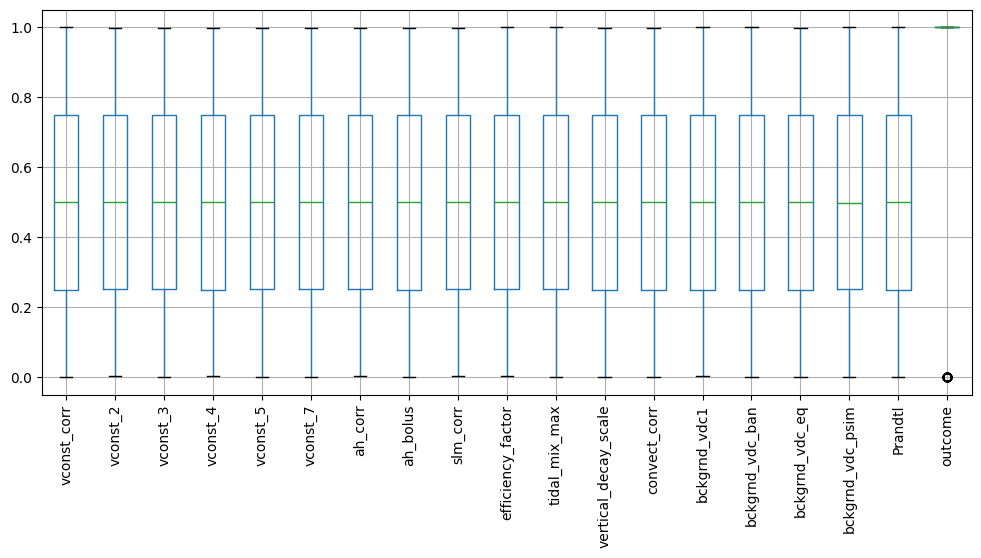

In [ ]:
# Checking for outliers

data.boxplot(figsize=(12,5))
plt.xticks(rotation=90)
plt.show()

The boxplot shows no meaningful outliers across features — the data is clean.

### Exploratory Data Analysis

Text(0, 0.5, 'Count')

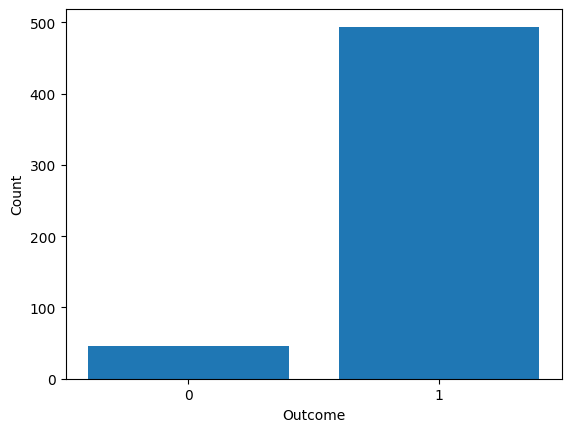

In [ ]:
# Exploratory Data Analysis: Frequency distribution of target variable

data['outcome'].hist(bins=[-0.5, 0.5, 1.5], rwidth=0.8, grid=False)
plt.xticks([0, 1])
plt.xlabel("Outcome")
plt.ylabel("Count")

The target is class-imbalanced: the majority of simulations complete successfully (outcome = 1), with crashes (outcome = 0) being the minority class. This is addressed in the SVM models using `class_weight='balanced'` where appropriate.

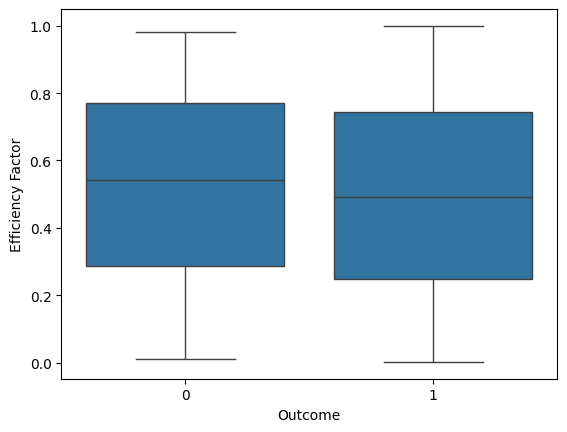

In [ ]:
# Exploratory Data Analysis: Association #1 - Outcome v. Efficiency Factor

sns.boxplot(x='outcome', y='efficiency_factor', data=data)
plt.xlabel("Outcome")
plt.ylabel("Efficiency Factor")
plt.show()

No meaningful separation between crash and non-crash outcomes is visible along the `efficiency_factor` axis — this feature may contribute little discriminative signal on its own.

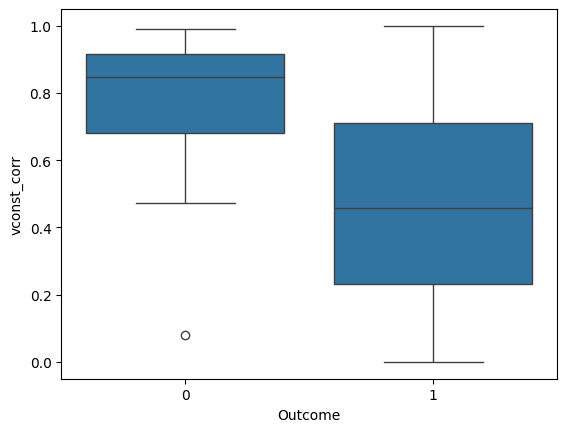

In [ ]:
# Exploratory Data Analysis: Association #2 - Outcome v. vconst_corr

sns.boxplot(x='outcome', y='vconst_corr', data=data)
plt.xlabel("Outcome")
plt.ylabel("vconst_corr")
plt.show()

`vconst_corr` tends to be higher for crashed simulations (outcome = 0) and lower for successful ones. This suggests it carries useful discriminative information.

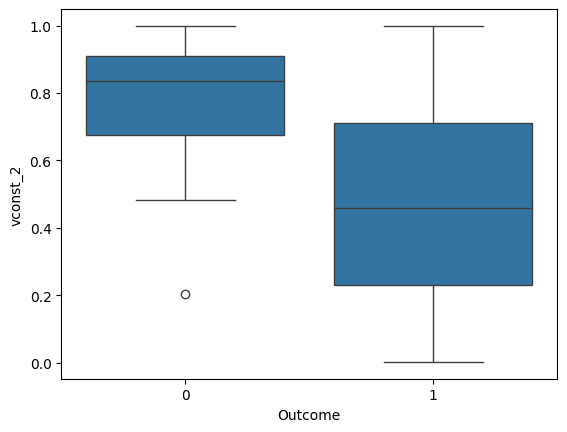

In [ ]:
# Exploratory Data Analysis: Association #3 - Outcome v. vconst_2

sns.boxplot(x='outcome', y='vconst_2', data=data)
plt.xlabel("Outcome")
plt.ylabel("vconst_2")
plt.show()

A similar pattern holds for `vconst_2` — higher values associate with crashes, lower values with successful runs.

### Feature Matrix & Train/Test Split

In [ ]:
# Splitting and scaling dataset

X = data.drop('outcome', axis=1)
y = data['outcome']
np.random.seed(42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42, stratify=y)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

results = []

The dataset is split 67/33 into training and test sets with stratification to preserve the class ratio. StandardScaler is fitted on training data only.

## SVM Kernel Comparison

Four kernels are evaluated with default hyperparameters as a baseline comparison. `class_weight='balanced'` is applied to the polynomial, RBF, and sigmoid kernels to account for class imbalance.

### Linear Kernel

0.9608938547486033


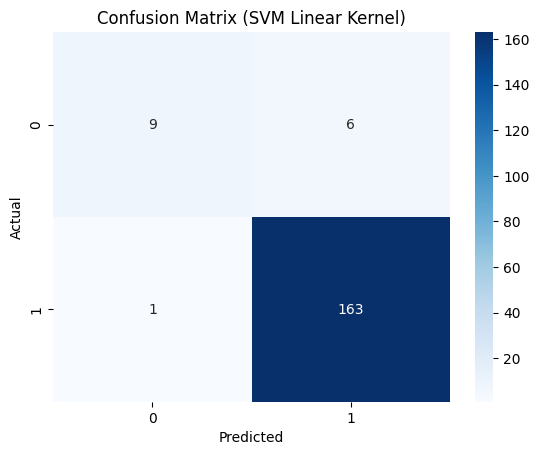

              precision    recall  f1-score   support

           0       0.90      0.60      0.72        15
           1       0.96      0.99      0.98       164

    accuracy                           0.96       179
   macro avg       0.93      0.80      0.85       179
weighted avg       0.96      0.96      0.96       179



In [ ]:
# Fitting SVM model on the training data using Linear kernel

svm_linear = SVC(kernel="linear")
svm_linear.fit(X_train, y_train)

y_pred_linear = svm_linear.predict(X_test)
acc = accuracy_score(y_test, y_pred_linear)
cm = confusion_matrix(y_test, y_pred_linear)

print(acc)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (SVM Linear Kernel)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, y_pred_linear))

results.append({
        "Model": "Linear SVM",
        "Accuracy": acc
    })

**Accuracy = 0.961** — the linear kernel performs best among all baseline kernels, suggesting the classes are largely linearly separable in the feature space. High recall (0.99) indicates very few crashes are missed.

### Polynomial Kernel

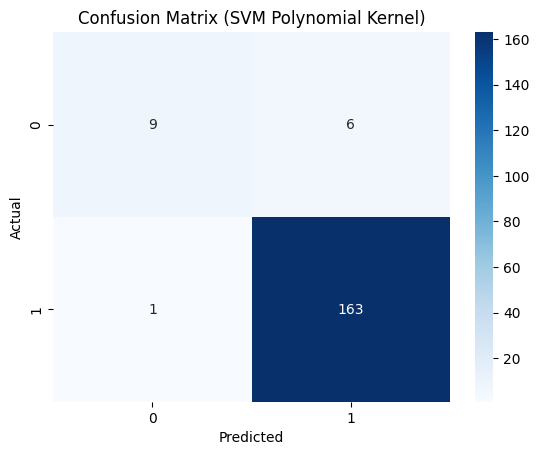

0.9162011173184358
              precision    recall  f1-score   support

           0       0.50      0.07      0.12        15
           1       0.92      0.99      0.96       164

    accuracy                           0.92       179
   macro avg       0.71      0.53      0.54       179
weighted avg       0.89      0.92      0.89       179



In [ ]:
# Fitting SVM model on the training data using Polynomial kernel

svm_poly = SVC(kernel="poly", class_weight="balanced")
svm_poly.fit(X_train, y_train)

y_pred_poly = svm_poly.predict(X_test)
acc = accuracy_score(y_test, y_pred_poly)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (SVM Polynomial Kernel)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(acc)
print(classification_report(y_test, y_pred_poly))

results.append({
        "Model": "Polynomial SVM",
        "Accuracy": acc
    })

**Accuracy = 0.916** — solid performance but a step below the linear kernel. The added complexity of the polynomial mapping does not improve results here.

### RBF Kernel

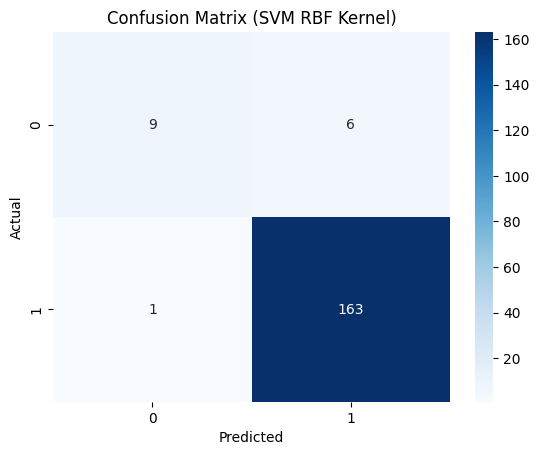

0.9273743016759777
              precision    recall  f1-score   support

           0       0.62      0.33      0.43        15
           1       0.94      0.98      0.96       164

    accuracy                           0.93       179
   macro avg       0.78      0.66      0.70       179
weighted avg       0.91      0.93      0.92       179



In [ ]:
# Fitting SVM model on the training data using RBF kernel

svm_rbf = SVC(kernel="rbf", class_weight = "balanced")
svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)
acc = accuracy_score(y_test, y_pred_rbf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (SVM RBF Kernel)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(acc)
print(classification_report(y_test, y_pred_rbf))

results.append({
        "Model": "RBF SVM",
        "Accuracy": acc
    })

**Accuracy = 0.927** — the RBF kernel performs between the linear and polynomial baselines. Its performance is a candidate for improvement through hyperparameter tuning.

### Sigmoid Kernel

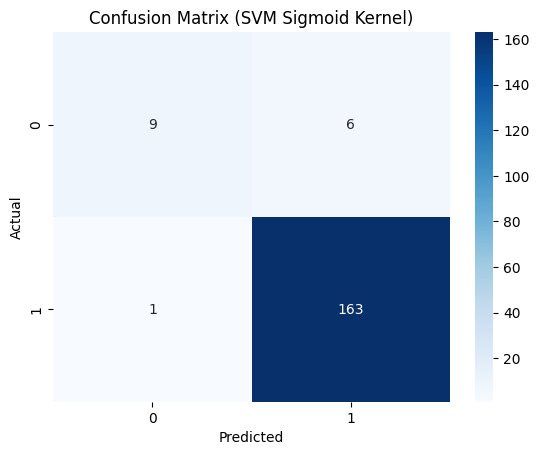

0.8491620111731844
              precision    recall  f1-score   support

           0       0.32      0.73      0.45        15
           1       0.97      0.86      0.91       164

    accuracy                           0.85       179
   macro avg       0.65      0.80      0.68       179
weighted avg       0.92      0.85      0.87       179



In [ ]:
# Fitting SVM model on the training data using Sigmoid kernel

svm_sigmoid = SVC(kernel="sigmoid", class_weight = "balanced")
svm_sigmoid.fit(X_train, y_train)

y_pred_sigmoid = svm_sigmoid.predict(X_test)
acc = accuracy_score(y_test, y_pred_sigmoid)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (SVM Sigmoid Kernel)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(acc)
print(classification_report(y_test, y_pred_sigmoid))

results.append({
        "Model": "Sigmoid SVM",
        "Accuracy": acc
    })

**Accuracy = 0.849** — the sigmoid kernel is the weakest performer among the four, with noticeably lower recall compared to the other kernels.

## Hyperparameter Tuning (GridSearchCV)

Best Parameters: {'C': 10, 'gamma': 0.01}


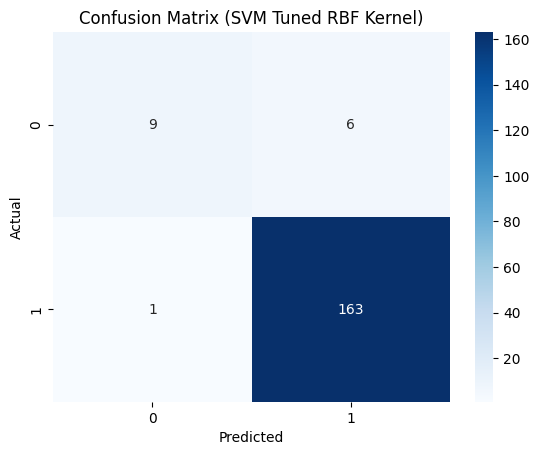

0.9441340782122905 

              precision    recall  f1-score   support

           0       1.00      0.33      0.50        15
           1       0.94      1.00      0.97       164

    accuracy                           0.94       179
   macro avg       0.97      0.67      0.74       179
weighted avg       0.95      0.94      0.93       179



In [ ]:
# Using GridSearchCV to find optimal C and Gamma for RBF kernel

param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.01, 0.1, 1]
}

grid_svm = GridSearchCV(
    SVC(kernel="rbf"),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
# Training tuned SVM RBF model on training set and predicting on testing set

grid_svm.fit(X_train, y_train)

best_svm = grid_svm.best_estimator_
y_pred_best = best_svm.predict(X_test)

print("Best Parameters:", grid_svm.best_params_)

acc = accuracy_score(y_test, y_pred_best)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (SVM Tuned RBF Kernel)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(acc, "\n")
print(classification_report(y_test, y_pred_best))

results.append({
        "Model": "Tuned RBF SVM",
        "Accuracy": acc
    })



GridSearchCV with 5-fold cross-validation is used to tune `C` and `gamma` for the RBF kernel. The optimal parameters are **C = 10, gamma = 0.01**.

The tuned RBF model achieves **accuracy = 0.944** and **recall = 1.00** — a meaningful improvement over the untuned RBF baseline (0.927), though still slightly below the linear kernel's accuracy (0.961). The perfect recall is notable: no crashed simulations are missed.

## Model Comparison & Final Evaluation

In [ ]:
results_df = pd.DataFrame(results)
results_df.sort_values(by="Accuracy", ascending=False, inplace=True)
results_df

,Model,Accuracy
0,Linear SVM,0.960894
4,Tuned RBF SVM,0.944134
2,RBF SVM,0.927374
1,Polynomial SVM,0.916201
3,Sigmoid SVM,0.849162


The linear kernel remains the top performer by accuracy. However, the tuned RBF model achieves perfect recall (1.00) — a meaningful property in a safety-relevant context where missing a crash is costly.

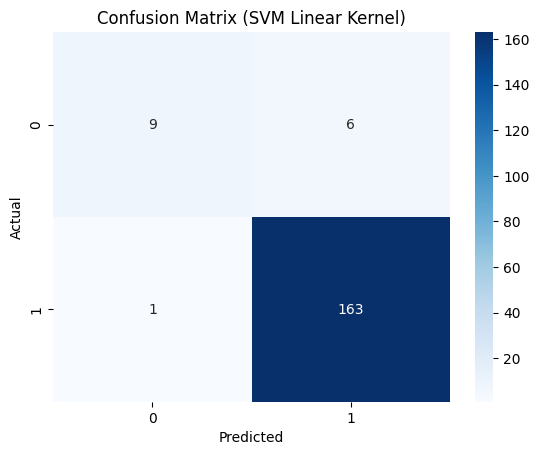

In [ ]:
# Confusion matrix for best performing model

cm = confusion_matrix(y_test, y_pred_linear)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (SVM Linear Kernel)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Linear kernel — final evaluation:**

| Metric | Value |
|---|---|
| Accuracy | 0.961 |
| Sensitivity (Recall) | 0.994 |
| Specificity | 0.600 |
| Precision | 0.964 |

TP = 163, FP = 6, TN = 9, FN = 1

The high sensitivity (99.4%) means the model almost never misses a simulation crash. Specificity is lower (60%), reflecting the difficulty of correctly identifying the minority non-crash class.

## Conclusions

This project evaluated four SVM kernels for classifying climate model simulation crashes.

| Model | Accuracy |
|---|---|
| **Linear SVM** | **0.961** |
| Tuned RBF SVM | 0.944 |
| RBF SVM | 0.927 |
| Polynomial SVM | 0.916 |
| Sigmoid SVM | 0.849 |

**Key takeaways:**
- The **linear kernel** achieves the highest accuracy (96.1%), suggesting the crash/non-crash boundary is largely linearly separable in this feature space.
- **Hyperparameter tuning** improved the RBF kernel meaningfully (92.7% → 94.4%) and pushed its recall to a perfect 1.00 — no crashes missed.
- The **sigmoid kernel** was the weakest performer, consistent with its known sensitivity to feature scaling and hyperparameter choice.
- The class imbalance (crashes are the minority) makes recall a particularly important metric here — a missed crash is a more costly error than a false alarm.

**Potential next steps:** Applying SMOTE or class weighting more systematically, tuning the linear kernel's `C` parameter, or exploring ensemble methods for further accuracy gains.